# Assignment 0

Work through Tasks 1-4 below. You can reuse the Lecture 1 demo notebook materials.

Things to submit:

1. This notebook with all outputs.
2. The file `width_sweep.csv` in Task 4.

Requirements: `numpy`, `matplotlib`, `scikit-learn`, `xgboost`, `torch`.

In [ ]:
# Install required modules:
# %pip install numpy
# %pip install matplotlib
# %pip install scikit-learn
# %pip install xgboost
# %pip install torch

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ------------- -------------------------- 3.1/9.3 MB 18.7 MB/s eta 0:00:01
   ------------------------------- -------- 7.3/9.3 MB 18.4 MB/s eta 0:00:01
   ---------------------------------------- 9.3/9.3 MB 17.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   ---------------------------------------- 2.5/2.5 MB 11.9 MB/s eta 0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ------------------------------ --------- 5.5/7.2 MB 26.3 MB/s eta 0:00:01
   ---------------------------------------- 7.2/7.2 MB 24.4 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Setup

Please run the following without modification. If you meet error, please check whether the libraries are installed successfully.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

X, y = make_moons(n_samples=400, noise=0.20, random_state=0)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=0)

Xtr_t = torch.tensor(Xtr, dtype=torch.float32)
ytr_t = torch.tensor(ytr, dtype=torch.float32).unsqueeze(1)
Xte_t = torch.tensor(Xte, dtype=torch.float32)
yte_t = torch.tensor(yte, dtype=torch.float32).unsqueeze(1)

BATCH_SIZE = 32
STEPS_PER_EPOCH = int(np.ceil(len(Xtr) / BATCH_SIZE))
print("train:", Xtr.shape, " test:", Xte.shape, " steps/epoch:", STEPS_PER_EPOCH)

train: (280, 2)  test: (120, 2)  steps/epoch: 9


In [2]:
def plot_decision_boundary(predict_fn, X, y, title="", ax=None, h=0.02):
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 4))
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = np.asarray(predict_fn(np.c_[xx.ravel(), yy.ravel()])).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap="coolwarm")
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", s=18, edgecolor="k", linewidth=0.3)
    ax.set_title(title); ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")
    return ax


@torch.no_grad()
def accuracy(model, X_t, y_t):
    pred = (torch.sigmoid(model(X_t)) > 0.5).float()
    return (pred == y_t).float().mean().item()


def epoch_average(losses):
    return np.array(losses).reshape(-1, STEPS_PER_EPOCH).mean(axis=1)

---
## Task 1

Fit logistic regression and XGBoost on `make_moons`, and then report train/test accuracy.

In [3]:
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# TODO: fit a LogisticRegression on (Xtr, ytr) and print train and test accuracy.
clf = LogisticRegression()
clf.fit(Xtr, ytr)
print("Logistic regression:")
print("train acc:", clf.score(Xtr, ytr))
print("test acc:", clf.score(Xte, yte), "\n")

# TODO: fit an XGBClassifier (n_estimators=200, max_depth=3, learning_rate=0.1,
#       eval_metric="logloss") and print train and test accuracy.
bst = XGBClassifier(n_estimators=200, max_depth=3,
                    learning_rate=0.1, eval_metric="logloss")
bst.fit(Xtr, ytr)
print("XGBoost:")
print("train acc:", bst.score(Xtr, ytr))
print("test acc:", bst.score(Xte, yte),"\n")

Logistic regression:
train acc: 0.8571428571428571
test acc: 0.9083333333333333 

XGBoost:
train acc: 0.9964285714285714
test acc: 0.95 



---
## Task 2

Train a two-layer MLP. Plot (i) the loss curve and (ii) the decision-boundary plot.

In the following, please first define the class of neural network.

In [4]:
class TwoLayerMLP(nn.Module):
    def __init__(self, d_in=2, width=64):
        super().__init__()
        # TODO: define the components used in the model
        self.fc1 = nn.Linear(d_in, width)
        self.fc2 = nn.Linear(width, 1)

    def forward(self, x):
        # TODO: specify how the components are used to compute the output in the forward pass
        h = torch.relu(self.fc1(x))
        return self.fc2(h)

In the following, write the training loop. With the training loop wrapped in a function, Tasks 3 and 4 can then re-run it with different `width` and `lr`. 

In [5]:
def train_mlp(model, width=64, lr=0.1, epochs=100, seed=0, batch_size=BATCH_SIZE):
    '''
    Train a TwoLayerMLP on (Xtr_t, ytr_t).

    Returns
    -------
    model  : the trained TwoLayerMLP
    losses : list of per-step/per-epoch losses
    '''
    torch.manual_seed(seed)     # Keep this. It makes your results reproducible

    # TODO: follow the course demo code to train the model.
    ds = TensorDataset(Xtr_t, ytr_t)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=True)

    loss_fn = nn.BCEWithLogitsLoss()

    opt = torch.optim.SGD(model.parameters(), lr=lr)

    losses = []

    for epoch in range(epochs):
        for xb, yb in loader:
            opt.zero_grad()                  # clear old gradients
            logits = model(xb)               # forward -> prediction
            loss = loss_fn(logits, yb)       # empirical risk on batch
            loss.backward()                  # gradients (chain rule)
            opt.step()                       # theta <- theta - eta * grad
            losses.append(loss.item())

    return model, losses        



In [6]:
# Looks like we need to define the model first.
torch.manual_seed(0)    # Set a random seed here. Can't wait until running train_mlp.
model = TwoLayerMLP(d_in=2, width=64)

In [7]:
model, losses = train_mlp(model, width=64, lr=0.1, epochs=100)
print(f"MLP | train acc: {accuracy(model, Xtr_t, ytr_t):.3f}   "
      f"test acc: {accuracy(model, Xte_t, yte_t):.3f}")

MLP | train acc: 0.911   test acc: 0.942


**Plot (i): the loss curve.** The raw per-step curve is noisy because each point is
$\widehat{R}_{S_t}$ on a single mini-batch, not $\widehat{R}_S$ on the full sample. Please also use
`epoch_average(losses)` for a readable trend.

In [ ]:
# # This code block is only for testing.
# print(len(losses))
# print(losses[0:5])
# avg_losses = epoch_average(losses)
# print(avg_losses.shape)
# print(avg_losses[0:5])
# print(STEPS_PER_EPOCH)
# np.arange(len(avg_losses))*STEPS_PER_EPOCH + np.ceil(STEPS_PER_EPOCH/2)

array([  5.,  14.,  23.,  32.,  41.,  50.,  59.,  68.,  77.,  86.,  95.,
       104., 113., 122., 131., 140., 149., 158., 167., 176., 185., 194.,
       203., 212., 221., 230., 239., 248., 257., 266., 275., 284., 293.,
       302., 311., 320., 329., 338., 347., 356., 365., 374., 383., 392.,
       401., 410., 419., 428., 437., 446., 455., 464., 473., 482., 491.,
       500., 509., 518., 527., 536., 545., 554., 563., 572., 581., 590.,
       599., 608., 617., 626., 635., 644., 653., 662., 671., 680., 689.,
       698., 707., 716., 725., 734., 743., 752., 761., 770., 779., 788.,
       797., 806., 815., 824., 833., 842., 851., 860., 869., 878., 887.,
       896.])

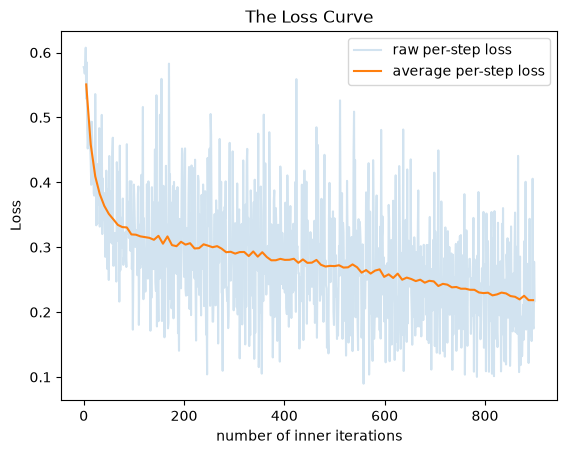

In [ ]:
# TODO: fill in your code.
avg_losses = epoch_average(losses)  # Note that epoch_average has already been defined.

# raw per-step curve
plt.plot(losses, alpha=0.2, label="raw per-step loss")

# average per-step curve
center_of_epoch = np.arange(len(avg_losses))*STEPS_PER_EPOCH + np.ceil(STEPS_PER_EPOCH/2)
plt.plot(center_of_epoch, avg_losses, label="average per-step loss")

plt.xlabel("number of inner iterations")
plt.ylabel("Loss")
plt.title("The Loss Curve")
plt.legend()
plt.show()

**Plot (ii): the decision boundary.** Please check the implementation of `plot_decision_boundary` and use it to make the plot.

In [ ]:
# TODO: fill in your code.

---
## Task 3

Vary the learning rate $\eta \in \{0.01, 0.1, 1.0, 5.0\}$. Plot all loss curves on one axis.
Identify the value where training diverges.

Hint: please start from a raw model in each trial. Do not use a trained model to continue the training in another setting.

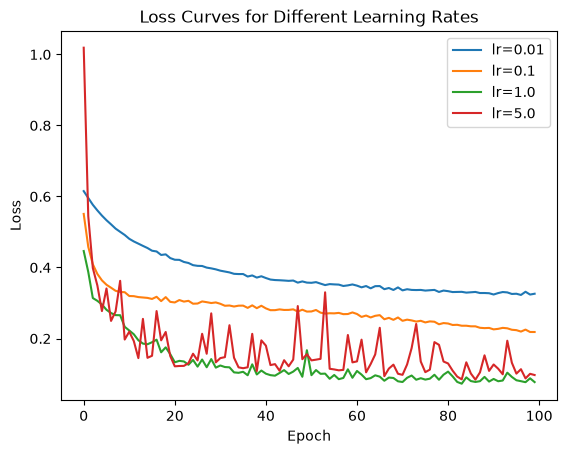

In [28]:
lrs = [0.01, 0.1, 1.0, 5.0]

# TODO: fill in your code.
for lr in lrs:
    # Initialize the model:
    torch.manual_seed(0)
    model_lr = TwoLayerMLP(d_in=2, width=64)

    # Train:
    model_lr, losses_lr = train_mlp(model_lr, width=64, lr=lr, epochs=100)

    # Plot:
    avg_losses_lr = epoch_average(losses_lr)

    plt.plot(avg_losses_lr, label=f"lr={lr}")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curves for Different Learning Rates")
plt.legend()
plt.show()    


# TODO: type as a comment in the code: under what lr does the loss curve diverge?
# Answer: The loss curve probably diverges when lr = 5.0. The curve indeed has a decreasing trend, 
# but it is still not stable at the end of the training.

---
## Task 4

Vary the width $\in \{2, 8, 64, 512\}$. Record train and test accuracy for each.

In [ ]:
widths = [2, 8, 64, 512]
rows = []

# TODO: fill in your code.
for width in widths:
    # Initialize the model:
    torch.manual_seed(0)
    model_width = TwoLayerMLP(d_in=2, width=width)

    # Train:
    model_width, losses_width = train_mlp(model_width, width=width, lr=0.1, epochs=100)

    # Compute and record accuracies:
    train_acc = accuracy(model_width, Xtr_t, ytr_t)
    test_acc = accuracy(model_width, Xte_t, yte_t)

    rows.append([width, train_acc, test_acc])

# TODO: print the table.
import csv

with open("width_sweep.csv", "w", newline="") as csv_file:
    writer = csv.writer(csv_file)
    writer.writerow(["width", "train_acc", "test_acc"])
    writer.writerows(rows)